In [2]:
# ============================================================
# Molecular Causal Effect Estimation — Double/Debiased Machine Learning (DML)
# ============================================================
# Dependencies: pip install econml dowhy pandas openpyxl scikit-learn matplotlib
#
# Method: Double Machine Learning (DML / Partially Linear Regression)
#   Chernozhukov et al. 2018 "Double/Debiased Machine Learning"
#
# 5 Causal Relationships:
#   1. Electron-Withdrawing Group (EWG) → HOMO_A (acceptor HOMO)
#   2. Electron-Withdrawing Group (EWG) → LUMO_A (acceptor LUMO)
#   3. Electron-Donating Group (EDG) → HOMO_D (donor HOMO)
#   4. Conjugation Length → Bandgap EgA_opt (acceptor optical bandgap)
#   5. Number of Aromatic Rings → Conjugation Length
#
# Control variables (confounders): Molecular Weight (MW), Number of Rings (n_rings)
# ============================================================

# ── 0. Import Libraries ────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter
from scipy import stats

# EconML DML
from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 12, "figure.dpi": 130})

print("✓ All libraries loaded successfully")

✓ All libraries loaded successfully


In [3]:
# ── 1. Load Data ──────────────────────────────────────────────
df = pd.read_excel("Data_Merged_with_SMILES.xlsx")
print(f"Data dimensions: {df.shape}  |  Columns: {df.columns.tolist()}")

Data dimensions: (1573, 18)  |  Columns: ['Voc', 'Jsc', 'FF', 'PCE', 'HOMO_A', 'LUMO_A', 'EgCV_A', 'λ_A_absorption', 'EgA_opt', 'HOMO_D', 'LUMO_D', 'EgCV_D', 'λ_D_absorption', 'EgD_opt', 'Acceptor', 'SMILES_acc', 'Donor', 'SMILES_don']


In [4]:
# ── 2. SMILES Feature Extraction (without RDKit) ────────────────────────
def extract_features(smiles: str) -> dict:
    """
    Extract molecular descriptors from SMILES string:
      ewg   : Electron-withdrawing group count (cyano, halogen, carbonyl, sulfonyl)
      edg   : Electron-donating group count (alkoxy, amine, thioether)
      mw    : Approximate molecular weight (Da)
      nrings: Total number of rings (estimated from ring closure digits)
      narom : Number of aromatic rings (ring closure on aromatic atoms)
      conj  : Conjugation length proxy (longest contiguous aromatic/unsaturated segment)
    """
    # Electron-withdrawing groups (EWG)
    ewg = (
        smiles.count("C#N")                           # cyano
        + len(re.findall(r"C\(=O\)", smiles))         # carbonyl C=O
        + len(re.findall(r"c\(=O\)", smiles))         # aromatic carbonyl
        + smiles.count("F")                            # fluorine
        + len(re.findall(r"Cl(?=[^a-z]|$)", smiles))  # chlorine
        + len(re.findall(r"Br(?=[^a-z]|$)", smiles))  # bromine
        + len(re.findall(r"S\(=O\)\(=O\)", smiles))   # sulfonyl
    )

    # Electron-donating groups (EDG)
    edg = (
        len(re.findall(r"OC", smiles))        # alkoxy
        + len(re.findall(r"N\(", smiles))     # tertiary / secondary amine
        + len(re.findall(r"SC[^#=]", smiles)) # thioether
    )

    # Molecular weight (character-by-character parsing)
    atom_mw = {
        "C": 12.011, "c": 12.011,
        "N": 14.007, "n": 14.007,
        "O": 15.999, "o": 15.999,
        "S": 32.065, "s": 32.065,
        "F": 18.998, "P": 30.974,
    }
    mw = 0.0
    i = 0
    while i < len(smiles):
        two = smiles[i : i + 2]
        if two == "Cl":   mw += 35.45;  i += 2; continue
        if two == "Br":   mw += 79.90;  i += 2; continue
        if two == "Si":   mw += 28.09;  i += 2; continue
        if smiles[i] in atom_mw:
            mw += atom_mw[smiles[i]]
        i += 1

    # Total rings (each ring closure appears twice = 1 ring)
    ring_ids = re.findall(r"%\d{2}|\d", smiles)
    c = Counter(ring_ids)
    nrings = sum(1 for v in c.values() if v >= 2)

    # Aromatic rings (unique ring closures on aromatic atoms)
    arom_tokens = re.findall(r"[cnos](?:%\d{2}|\d)", smiles)
    narom = len(set(re.findall(r"%\d{2}|\d", "".join(arom_tokens))))

    # Conjugation length (longest contiguous aromatic/unsaturated segment)
    conj = max(
        (len(m.group()) for m in re.finditer(r"[a-z=\\/]+", smiles)),
        default=0,
    )

    return {"ewg": ewg, "edg": edg, "mw": mw, "nrings": nrings,
            "narom": narom, "conj": conj}


for role, col in [("acc", "SMILES_acc"), ("don", "SMILES_don")]:
    feats = df[col].apply(extract_features)
    for key in ["ewg", "edg", "mw", "nrings", "narom", "conj"]:
        df[f"{key}_{role}"] = feats.apply(lambda x: x[key])

print("✓ Molecular feature extraction completed")
feat_cols = [c for c in df.columns
             if any(c.startswith(p) for p in ["ewg","edg","mw","nrings","narom","conj"])]
print(df[feat_cols].describe().round(2).to_string())

✓ Molecular feature extraction completed
       ewg_acc  edg_acc   mw_acc  nrings_acc  narom_acc  conj_acc  ewg_don  edg_don   mw_don  nrings_don  narom_don  conj_don
count  1573.00  1573.00  1573.00     1573.00    1573.00   1573.00  1573.00  1573.00  1573.00     1573.00    1573.00   1573.00
mean      8.53     0.49  1373.74       10.14       9.47      3.74     3.91     1.36  1395.90        8.99       6.10      2.97
std       2.72     1.20   376.43        4.46       4.41      0.91     3.48     1.72   488.33        5.48       6.72      1.36
min       0.00     0.00   412.39        2.00       0.00      1.00     0.00     0.00   450.38        2.00       0.00      1.00
25%       6.00     0.00  1221.96        6.00       6.00      3.00     2.00     0.00  1143.26        2.00       0.00      1.00
50%      10.00     0.00  1389.29       12.00      12.00      4.00     3.00     0.00  1167.28        9.00       2.00      4.00
75%      10.00     0.00  1437.34       13.00      12.00      4.00     6.00   

In [5]:
# ── 3. DML Causal Estimation Helper Function ───────────────────────────────
def make_gbm():
    """Gradient boosting regressor (for first-stage residual regression)"""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=42
        )),
    ])

def run_dml(T: np.ndarray, Y: np.ndarray, W: np.ndarray,
            label_T: str, label_Y: str, alpha: float = 0.05):
    """
    Run LinearDML and return ATE with confidence interval.

    Parameters
    ----------
    T : (n,1) treatment
    Y : (n,)  outcome
    W : (n,p) confounders
    label_T, label_Y : names for printing
    alpha : significance level (0.05 → 95% CI)

    Returns
    -------
    dict : {ate, ci_lower, ci_upper, se, pvalue}
    """
    # LinearDML: Y ~ θ·T + g(W) + ε, uses cross-fitting to eliminate regularization bias
    est = LinearDML(
        model_y=make_gbm(),   # first-stage model for E[Y|W]
        model_t=make_gbm(),   # first-stage model for E[T|W]
        linear_first_stages=False,
        cv=5,
        random_state=42,
    )
    est.fit(Y, T, X=None, W=W)

    ate = float(est.const_marginal_effect(X=None).squeeze())
    inf = est.const_marginal_effect_inference(X=None)
    ci = inf.conf_int(alpha=alpha)
    ci_lo = float(np.atleast_1d(ci[0]).squeeze())
    ci_hi = float(np.atleast_1d(ci[1]).squeeze())

    ci_lo = float(np.atleast_1d(ci[0]).squeeze())
    ci_hi = float(np.atleast_1d(ci[1]).squeeze())
    # CI = ATE ± 1.96 × SE  →  SE = (upper - lower) / (2 × 1.96)
    se = (ci_hi - ci_lo) / (2 * 1.96)
    pval = float(2 * (1 - stats.norm.cdf(abs(ate / se)))) if se > 0 else 1.0

    print(f"\n{'─'*56}")
    print(f"  Treatment (T) : {label_T}")
    print(f"  Outcome (Y)   : {label_Y}")
    print(f"  Controls (W)  : Molecular weight, Number of rings")
    print(f"  ATE           : {ate:+.4f}")
    print(f"  95% CI        : [{ci_lo:+.4f},  {ci_hi:+.4f}]")
    print(f"  SE            : {se:.4f}")
    print(f"  p-value       : {pval:.4e}")
    print(f"  Conclusion    : {'Significant ✓' if pval < 0.05 else 'Not significant ✗'}")

    return {"label_T": label_T, "label_Y": label_Y,
            "ate": ate, "ci_lower": ci_lo, "ci_upper": ci_hi,
            "se": se, "pvalue": pval}


In [6]:
# ── 4. Define 5 Causal Analysis Tasks ──────────────────────────────
# Control variables: (mw_acc, nrings_acc) for acceptors, (mw_don, nrings_don) for donors
# Conjugation→Bandgap / Aromatic rings→Conjugation use acceptor molecules

tasks = [
    # (T column,     Y column,    W column list,             T label,                 Y label)
    ("ewg_acc",  "HOMO_A",  ["mw_acc",  "nrings_acc"],  "EWG count (acceptor)",  "HOMO_A (eV)"),
    ("ewg_acc",  "LUMO_A",  ["mw_acc",  "nrings_acc"],  "EWG count (acceptor)",  "LUMO_A (eV)"),
    ("edg_don",  "HOMO_D",  ["mw_don",  "nrings_don"],  "EDG count (donor)",    "HOMO_D (eV)"),
    ("conj_acc", "EgA_opt", ["mw_acc",  "nrings_acc"],  "Conjugation length (acceptor)","Bandgap EgA_opt (eV)"),
    ("narom_acc","conj_acc",["mw_acc",  "nrings_acc"],  "Aromatic rings (acceptor)","Conjugation length (acceptor)"),
]

results = []
for t_col, y_col, w_cols, lbl_t, lbl_y in tasks:
    sub = df[[t_col, y_col] + w_cols].dropna()
    T = sub[t_col].values.reshape(-1, 1).astype(float)
    Y = sub[y_col].values.astype(float)
    W = sub[w_cols].values.astype(float)
    res = run_dml(T, Y, W, lbl_t, lbl_y)
    results.append(res)

results_df = pd.DataFrame(results)
print("\n\n══ Summary Table ══════════════════════════════════════════════")
print(results_df[["label_T","label_Y","ate","ci_lower","ci_upper","se","pvalue"]]
      .to_string(index=False, float_format=lambda x: f"{x:+.4f}"))


────────────────────────────────────────────────────────
  Treatment (T) : EWG count (acceptor)
  Outcome (Y)   : HOMO_A (eV)
  Controls (W)  : Molecular weight, Number of rings
  ATE           : -0.0078
  95% CI        : [-0.0126,  -0.0031]
  SE            : 0.0024
  p-value       : 1.3132e-03
  Conclusion    : Significant ✓

────────────────────────────────────────────────────────
  Treatment (T) : EWG count (acceptor)
  Outcome (Y)   : LUMO_A (eV)
  Controls (W)  : Molecular weight, Number of rings
  ATE           : -0.0158
  95% CI        : [-0.0214,  -0.0102]
  SE            : 0.0029
  p-value       : 2.9500e-08
  Conclusion    : Significant ✓

────────────────────────────────────────────────────────
  Treatment (T) : EDG count (donor)
  Outcome (Y)   : HOMO_D (eV)
  Controls (W)  : Molecular weight, Number of rings
  ATE           : +0.0113
  95% CI        : [+0.0013,  +0.0212]
  SE            : 0.0051
  p-value       : 2.7115e-02
  Conclusion    : Significant ✓

───────────────

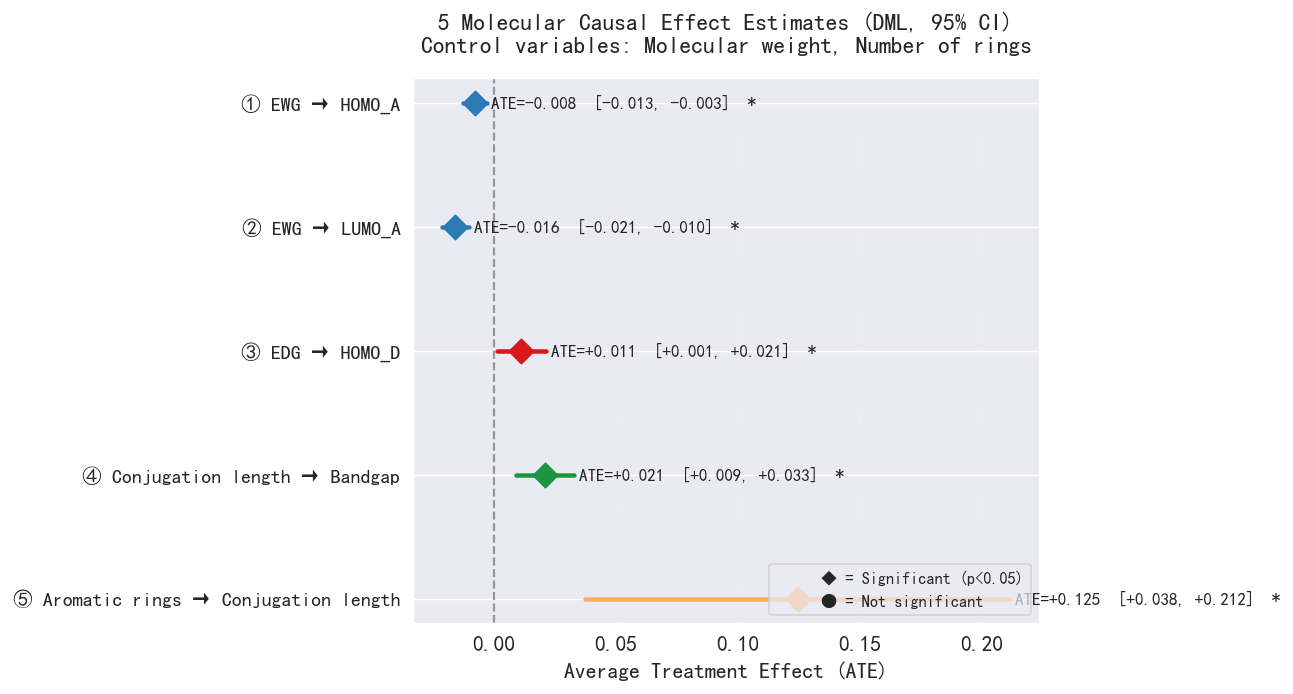


✓ Forest plot saved to causal_forest_plot.png


In [7]:
# ── 5. Visualization: Forest Plot ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

colors = ["#2c7bb6","#2c7bb6","#d7191c","#1a9641","#fdae61"]
labels = [
    "① EWG → HOMO_A",
    "② EWG → LUMO_A",
    "③ EDG → HOMO_D",
    "④ Conjugation length → Bandgap",
    "⑤ Aromatic rings → Conjugation length",
]

y_pos = np.arange(len(results))[::-1]

for i, (res, yp, col) in enumerate(zip(results, y_pos, colors)):
    ate, lo, hi = res["ate"], res["ci_lower"], res["ci_upper"]
    sig = res["pvalue"] < 0.05

    ax.plot([lo, hi], [yp, yp], color=col, lw=2.5, solid_capstyle="round")
    ax.scatter([ate], [yp], color=col, s=90, zorder=5,
               marker="D" if sig else "o")

    # Annotate values
    ax.text(max(hi, lo) + 0.002,
            yp, f"ATE={ate:+.3f}  [{lo:+.3f}, {hi:+.3f}]"
                + ("  *" if sig else ""),
            va="center", fontsize=9.5)

ax.axvline(0, color="gray", lw=1.2, ls="--", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Average Treatment Effect (ATE)", fontsize=12)
ax.set_title("5 Molecular Causal Effect Estimates (DML, 95% CI)\nControl variables: Molecular weight, Number of rings",
             fontsize=13, fontweight="bold", pad=14)
ax.grid(axis="x", alpha=0.3, ls=":")

# Legend
sig_patch   = mpatches.Patch(color="none", label="◆ = Significant (p<0.05)")
nosig_patch = mpatches.Patch(color="none", label="● = Not significant")
ax.legend(handles=[sig_patch, nosig_patch], loc="lower right",
          fontsize=9, framealpha=0.7)

plt.tight_layout()
plt.savefig("causal_forest_plot.png", bbox_inches="tight")
plt.show()
print("\n✓ Forest plot saved to causal_forest_plot.png")

In [8]:
# ── 6. First-Stage Fit Quality Diagnostics ──────────────────────────────
print("\n══ First-Stage R² Diagnostics (higher values indicate better confounding control) ══")
from sklearn.model_selection import cross_val_score

for t_col, y_col, w_cols, lbl_t, lbl_y in tasks:
    sub = df[[t_col, y_col] + w_cols].dropna()
    T = sub[t_col].values.reshape(-1, 1).astype(float)
    Y = sub[y_col].values.astype(float)
    W = sub[w_cols].values.astype(float)

    r2_y = cross_val_score(make_gbm(), W, Y, cv=5, scoring="r2").mean()
    r2_t = cross_val_score(make_gbm(), W, T.ravel(), cv=5, scoring="r2").mean()
    print(f"  {lbl_t:20s} → {lbl_y:24s} | R²(Y~W)={r2_y:.3f}  R²(T~W)={r2_t:.3f}")

print("\n✓ Analysis complete.")


══ First-Stage R² Diagnostics (higher values indicate better confounding control) ══
  EWG count (acceptor) → HOMO_A (eV)              | R²(Y~W)=-0.095  R²(T~W)=0.442
  EWG count (acceptor) → LUMO_A (eV)              | R²(Y~W)=-0.141  R²(T~W)=0.442
  EDG count (donor)    → HOMO_D (eV)              | R²(Y~W)=-0.205  R²(T~W)=0.024
  Conjugation length (acceptor) → Bandgap EgA_opt (eV)     | R²(Y~W)=-0.091  R²(T~W)=0.431
  Aromatic rings (acceptor) → Conjugation length (acceptor) | R²(Y~W)=0.431  R²(T~W)=0.973

✓ Analysis complete.
